# Volterra Integral Equation Solver

This notebook implements and tests a predictor-corrector solver for linear Volterra integro-differential equations with memory kernels. It is intended as a compact numerical prototype for non-Markovian amplitude dynamics.

**Notebook map**

1. Solver implementation
2. Numerical method summary
3. Scalar exponential-kernel test
4. Matrix/auxiliary-variable validation
5. Kernel inspection
6. Timestep convergence


In [1]:
def volterra_solver(times, omega0, kernel_values, memory_cutoff=None):
    dt = times[1] - times[0]
    N = len(times)
    u = np.zeros(N, dtype=complex)
    u[0] = 1.0
    
    if memory_cutoff is None:
        memory_steps = N
    else:
        memory_steps = int(np.ceil(memory_cutoff / dt))
        
    f_prev = None
    
    for n in range(N-1):
        # 1. Evaluate convolution at t_n
        start_n = max(0, n - memory_steps + 1)
        history_n = u[start_n : n+1]
        kernel_slice_n = kernel_values[: n - start_n + 1][::-1]
        
        conv_n = dt * np.dot(kernel_slice_n, history_n)
        f_n = -1j * omega0 * u[n] - conv_n
        
        # 2. Predictor (Euler / AB2)
        if n == 0:
            u_pred = u[n] + dt * f_n
        else:
            u_pred = u[n] + dt * (1.5 * f_n - 0.5 * f_prev)
            
        # 3. Evaluate convolution at t_{n+1} using u_pred
        start_pred = max(0, (n + 1) - memory_steps + 1)
        
        # Append the new predicted point to the history
        history_pred = np.append(u[start_pred : n+1], u_pred)
        
        # Shift the kernel slice one step forward
        kernel_slice_pred = kernel_values[: (n + 1) - start_pred + 1][::-1]
        
        conv_pred = dt * np.dot(kernel_slice_pred, history_pred)
        f_pred = -1j * omega0 * u_pred - conv_pred
        
        # 4. AM2 Corrector
        u[n+1] = u[n] + 0.5 * dt * (f_n + f_pred)
        f_prev = f_n
        
    return u

## 1. Solver implementation

Define the predictor-corrector Volterra solver. The code below is the core routine used in all later tests.

## Volterra Equation Solver: Predictor–Corrector Scheme

This function solves a linear integro-differential Volterra equation of the form

$$\dot u(t)=-i\omega_0 u(t)-\int_0^t K(t-\tau)\,u(\tau)\,d\tau ,\qquad u(0)=1 .$$

Here:

- $u(t)$ is the complex amplitude to be evolved.
- $\omega_0$ is the system frequency.
- $K(t-\tau)$ is the memory kernel.
- `kernel_values[j]` represents $K(t_j)$.
- `times` is the time grid.
- `memory_cutoff` optionally truncates the memory integral.

The convolution term at time $t_n$ is approximated by a discrete quadrature:

$$
\int_0^{t_n} K(t_n-\tau)u(\tau)d\tau
\approx
\Delta t \sum_{m=0}^{n} K(t_n-t_m)u(t_m).
$$

In code this appears as

```python
conv_n = dt * np.dot(kernel_slice_n, history_n)

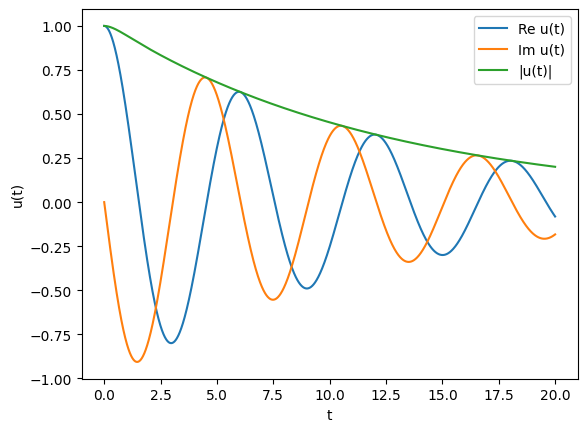

In [2]:
import numpy as np
import matplotlib.pyplot as plt

times = np.linspace(0, 20, 2001)
omega0 = 1.0
gamma = 0.2
lam = 2.0

kernel_values = gamma * np.exp(-lam * times)

u = volterra_solver(
    times=times,
    omega0=omega0,
    kernel_values=kernel_values,
    memory_cutoff=None
)

plt.plot(times, np.real(u), label="Re u(t)")
plt.plot(times, np.imag(u), label="Im u(t)")
plt.plot(times, np.abs(u), label="|u(t)|")
plt.xlabel("t")
plt.ylabel("u(t)")
plt.legend()
plt.show()

## 2. Scalar exponential-kernel test

Test the solver on a simple exponentially decaying memory kernel and plot the resulting complex amplitude.

Test 0 error: 4.163681104868777e-05


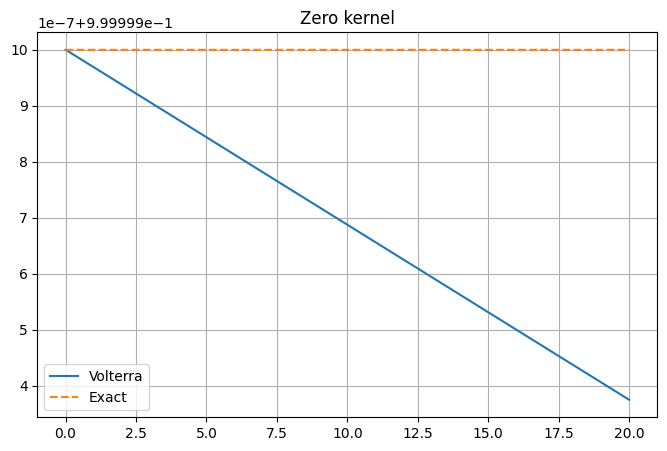

Exponential kernel error: 0.05762029028289687


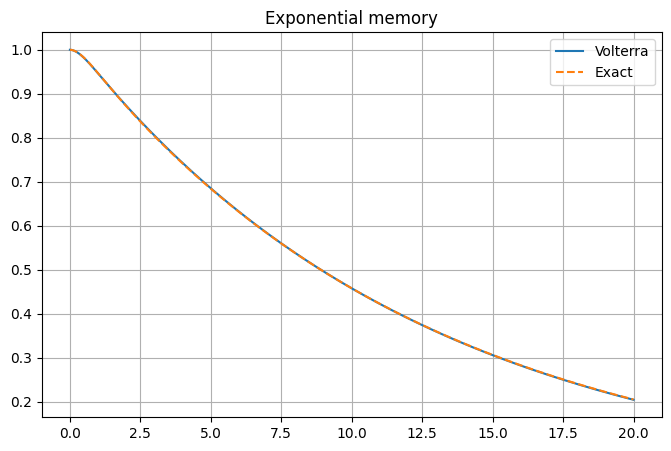

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import expm

omega0 = 1.0
tcut = 1.0

times = np.linspace(
    0,
    20,
    4001
)

# ============================================
# TEST 0
# ============================================

kernel_zero = np.zeros_like(times)

u_num = volterra_solver(
    times,
    omega0,
    kernel_zero
)

u_exact = np.exp(
    -1j*omega0*times
)

print(
    "Test 0 error:",
    np.max(np.abs(u_num-u_exact))
)

plt.figure(figsize=(8,5))

plt.plot(
    times,
    np.abs(u_num),
    label='Volterra'
)

plt.plot(
    times,
    np.abs(u_exact),
    '--',
    label='Exact'
)

plt.title("Zero kernel")
plt.grid()
plt.legend()
plt.show()

# ============================================
# TEST 1
# ============================================

gamma = 0.2
lam = 2.0

kernel_exp = gamma*np.exp(-lam*times)

u_num = volterra_solver(
    times,
    omega0,
    kernel_exp,
    memory_cutoff=tcut
)

M = np.array([
    [-1j*omega0,-1],
    [gamma,-lam]
],dtype=complex)

x0 = np.array([1,0],dtype=complex)

u_exact = np.array([
    (expm(M*t)@x0)[0]
    for t in times
])

print(
    "Exponential kernel error:",
    np.max(np.abs(u_num-u_exact))
)

plt.figure(figsize=(8,5))

plt.plot(
    times,
    np.abs(u_num),
    label='Volterra'
)

plt.plot(
    times,
    np.abs(u_exact),
    '--',
    label='Exact'
)

plt.title("Exponential memory")
plt.grid()
plt.legend()
plt.show()

## 3. Auxiliary-variable validation

Compare the Volterra solution against an equivalent enlarged Markovian system for an exponential kernel.

In [4]:
gamma*np.exp(-lam*times)

array([2.00000000e-01, 1.98009967e-01, 1.96039735e-01, ...,
       8.66835341e-19, 8.58210185e-19, 8.49670851e-19])

## 4. Kernel inspection

Inspect the memory kernel used in the validation problem.

dt= 0.10000  error=8.196e-01
dt= 0.05000  error=7.251e-01
dt= 0.02500  error=5.556e-01
dt= 0.01250  error=3.357e-01


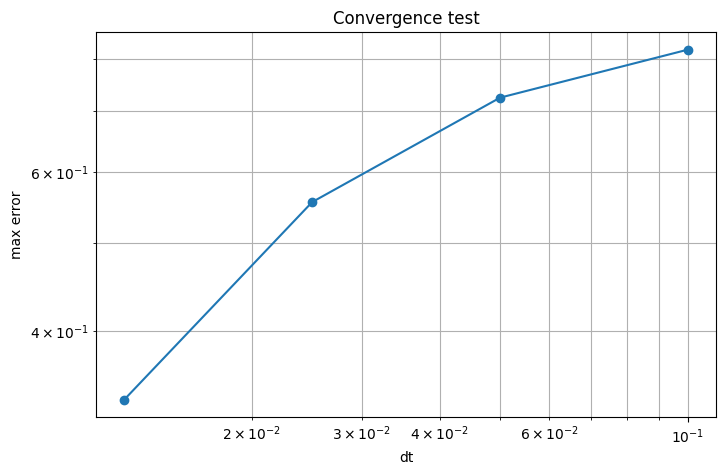

In [5]:
dt_values = [
    0.1,
    0.05,
    0.025,
    0.0125
]

errors = []

for dt in dt_values:

    times = np.arange(
        0,
        20+dt,
        dt
    )

    u_num = volterra_solver(
        times,
        omega0,
        kernel_exp
    )

    u_exact = np.array([
        (expm(M*t)@x0)[0]
        for t in times
    ])

    err = np.max(
        np.abs(u_num-u_exact)
    )

    errors.append(err)

    print(
        f"dt={dt:8.5f}  error={err:.3e}"
    )

plt.figure(figsize=(8,5))

plt.loglog(
    dt_values,
    errors,
    'o-'
)

plt.xlabel("dt")
plt.ylabel("max error")

plt.grid(True,which='both')

plt.title("Convergence test")

plt.show()

## 5. Timestep convergence

Repeat the calculation at several timesteps and estimate numerical convergence against a reference solution.